# Modeling

This notebook contains code for building the baseline and two improvement models. The baseline is a logistic regression model, the first improvement is a standard CNN, and the final improvement is an encoder-decoder CNN model (U-Net Style Architecture). Finally, there is some tuning done towards the end of the notebook.

## Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import Sequence

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.metrics import precision_recall_curve

## Connecting to Google Drive 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Uploading the Data

This section uploads the data and ensures it has the proper shapes.

In [3]:
# Declare data path
DATA_PATH = "/content/drive/MyDrive/wildfire-prediction-data/processed-data/"

In [4]:
# Declare input and output features again
INPUT_FEATURES = [
    'tmmn', 'tmmx', 'th', 'vs', 'pr', 'sph',
    'pdsi', 'NDVI', 'erc', 'population', 'elevation', 'PrevFireMask'
]
OUTPUT_FEATURE = 'FireMask'
GRID_SIZE = 64

In [5]:
# Load the numpy arrays
X_train = np.load(DATA_PATH + 'X_train.npy')
Y_train = np.load(DATA_PATH + 'Y_train.npy')
X_val   = np.load(DATA_PATH + 'X_val.npy')
Y_val   = np.load(DATA_PATH + 'Y_val.npy')
X_test  = np.load(DATA_PATH + 'X_test.npy')
Y_test  = np.load(DATA_PATH + 'Y_test.npy')

In [6]:
# Print out shapes of each array
for name, arr in [('X_train', X_train), ('Y_train', Y_train),
                  ('X_val', X_val), ('Y_val', Y_val),
                  ('X_test', X_test), ('Y_test', Y_test)]:
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}")

X_train: shape=(14979, 64, 64, 12), dtype=float32, min=-147.310, max=126.392
Y_train: shape=(14979, 64, 64), dtype=float32, min=-1.000, max=1.000
X_val: shape=(1877, 64, 64, 12), dtype=float32, min=-29.650, max=126.392
Y_val: shape=(1877, 64, 64), dtype=float32, min=-1.000, max=1.000
X_test: shape=(1689, 64, 64, 12), dtype=float32, min=-99.278, max=111.222
Y_test: shape=(1689, 64, 64), dtype=float32, min=-1.000, max=1.000


In [7]:
# Confirm the shapes (X should be N, 64, 64, 12)
assert X_train.shape[1:] == (GRID_SIZE, GRID_SIZE, len(INPUT_FEATURES)), \
    f"Unexpected X_train shape: {X_train.shape}"
assert Y_train.shape[1:] == (GRID_SIZE, GRID_SIZE), \
    f"Unexpected Y_train shape: {Y_train.shape}"

In [8]:
# Confirm Y label set matches the expectation of (-1, 0, 1)
print("\nUnique Y_train values:", np.unique(Y_train))
print("Unique Y_val values:", np.unique(Y_val))
print("Unique Y_test values:", np.unique(Y_test))


Unique Y_train values: [-1.  0.  1.]
Unique Y_val values: [-1.  0.  1.]
Unique Y_test values: [-1.  0.  1.]


Below is the function `build_combined_target`. This function creates one combined target array per split. For example:
- `combined[..., 0] = label` (dummy 0 where invalid)
- `combined[..., 1] = weight` (0 = ignore, pos_weight = fire, 1 = no-fire)
This function was created to manange memory issues due to Google Colab's limited RAM.

In [9]:
def build_combined_target(Y, pos_weight):
    Y = Y.astype(np.float32)
    label = np.where(Y == -1, 0.0, Y).astype(np.float32)
    weight = np.where(Y == -1, 0.0, np.where(Y == 1, pos_weight, 1.0)).astype(np.float32)
    return np.stack([label, weight], axis=-1)  # shape (N, 64, 64, 2)

n_fire = (Y_train == 1).sum()
n_nofire = (Y_train == 0).sum()
pos_weight = n_nofire / n_fire
print(f"pos_weight: {pos_weight:.2f}")

target_train = build_combined_target(Y_train, pos_weight)
target_val   = build_combined_target(Y_val, pos_weight)
target_test  = build_combined_target(Y_test, pos_weight)

del Y_train, Y_val, Y_test
import gc; gc.collect()

print("target_train shape:", target_train.shape, "(expect N,64,64,2)")
# !free -h

pos_weight: 90.02
target_train shape: (14979, 64, 64, 2) (expect N,64,64,2)


## Building the Baseline Model

This baseline model is equivalent to a 1x1 Convolutional Neural Network, which is equivalent to a logistic regression model. For this model, and the two improvements, we are using a Binary Cross-Entropy (BCE) loss function. While running the model, we found that simply selecting BCE as the loss function kept causing the Google Colab kernel to crash. So, due to the limited memory of Google Colab, we created the function `masked_weighted_bce`. This function accomplishes two things while computing BCE loss:
- Ignores invalid pixels (Y values = -1) 
- "Upweights" the fire-pixel class (due to how rare it is) so the model doesn't just learn to always predict "no fire".

Furthermore, the baseline model is also created below. For this simple model, we use the custom loss function, the Adam optimizer, a learning rate of 1e-3, and a batch size of 32. We also set the number of epochs to 50 but include an early stopping callback: `val_loss` is monitored with a patience of 5 epochs. 

In [10]:
# Loss function
def masked_weighted_bce(y_true, y_pred):
    label  = y_true[..., 0:1]
    weight = y_true[..., 1:2]
    y_pred = tf.sigmoid(y_pred)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = -(label * tf.math.log(y_pred) + (1 - label) * tf.math.log(1 - y_pred))
    weighted = bce * weight
    return tf.reduce_sum(weighted) / (tf.reduce_sum(weight) + 1e-7)

# Baseline model
def build_baseline_model():
    inputs = layers.Input(shape=(GRID_SIZE, GRID_SIZE, len(INPUT_FEATURES)))
    outputs = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(inputs)
    return models.Model(inputs, outputs, name='baseline_1x1_cnn')

baseline_model = build_baseline_model()
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=masked_weighted_bce)
print(f"Trainable params: {baseline_model.count_params()} (expect 13)")

Trainable params: 13 (expect 13)


Below is a class called `ArraySequence`. This class was created due to memory issues with Google Colab. It subclasses Keras's `Sequence` to create a custom generator that pulls batches directly from the existing in-memory NumPy arrays (X and y) via index slicing in `__getitem__`. This is done rather than trying to load the full dataset, which doesn't fit in the 12GB RAM of Google Colab. 

This class also handles shuffling (between individual datasets) manually. The function `on_epoch_end` reshuffles `self.indices` after each epoch completes. So, each epoch sees a completely different random ordering of batches. If this shuffling did not happen, the model would see the exact same batch groupings every epoch, which could lead the model to partially memorizing batch-level patterns rather than generalizing.

Also note that only the training data is shuffled; the validation data is not shuffled because its purpose is only for measuring performance, not learning.

In [11]:
class ArraySequence(Sequence):
    """Batches directly from existing numpy arrays — no copying, no tf.data shuffle buffer."""
    def __init__(self, X, y, batch_size, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        return self.X[batch_idx], self.y[batch_idx]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Build train/val generators
train_gen = ArraySequence(X_train, target_train, batch_size=8, shuffle=True)
val_gen = ArraySequence(X_val, target_val, batch_size=8, shuffle=False)

print(f"Train batches per epoch: {len(train_gen)}")
print(f"Val batches per epoch: {len(val_gen)}")

Train batches per epoch: 1873
Val batches per epoch: 235


In [12]:
# Create the early stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

# Checkpoint path
baseline_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/baseline_1x1_cnn_best.keras'

checkpoint_baseline = ModelCheckpoint(
    filepath=baseline_checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Run the model
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    batch_size=32, epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.7015 - val_loss: 0.6722
Epoch 2/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.6694 - val_loss: 0.6634
Epoch 3/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.6573 - val_loss: 0.6594
Epoch 4/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.6518 - val_loss: 0.6578
Epoch 5/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.6489 - val_loss: 0.6572
Epoch 6/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.6475 - val_loss: 0.6568
Epoch 7/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.6465 - val_loss: 0.6565
Epoch 8/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.6461 - val_loss: 0.6564
Epoch 9/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.6450 - val_loss: 0.6565
Epoch 10/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.6450 - val_loss: 0.6564
Epoch 11/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.6449 - val_loss: 0.6563
Epoch 12/50
1873/1

Below, the baseline model is evaluated using a few metrics: AUC (Area Under the Curve), Precision, Recall, F1, and IoU (Intersection over Union). Note that we are mainly focusing on how AUC turns out. This is due to the severe class-imbalance of 90:1 of no-fire to fire pixels in the data. AUC evaluates the model's performance across all possible decision thresholds, making it effectively threshold-dependent. So, AUC offers the most truthful look at how well the model is performing.

The metrics are all computed using `scikit-learn`'s various packages (listed in the Imports).

In [15]:
# Load the saved baseline checkpoint
baseline_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/baseline_1x1_cnn_best.keras'
baseline_model = tf.keras.models.load_model(
    baseline_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

# Get predictions
val_preds = baseline_model.predict(X_val, batch_size=64, verbose=1)

# Extract label and weight/mask channels from target_val
val_labels = target_val[..., 0]   # (N, 64, 64)
val_weights = target_val[..., 1]  
val_preds_flat = val_preds[..., 0]

# Build valid-pixel mask (weight > 0 means it was NOT an uncertain -1 pixel)
valid_mask = val_weights > 0

# Flatten and filter to valid pixels only
y_true = val_labels[valid_mask]
y_score = val_preds_flat[valid_mask]
y_pred_binary = (y_score >= 0.5).astype(int)

print(f"Valid pixels evaluated: {valid_mask.sum():,} / {valid_mask.size:,}")
print(f"Fire pixel rate among valid: {y_true.mean() * 100:.2f}%")

# Compute metrics
auc = roc_auc_score(y_true, y_score)
precision = precision_score(y_true, y_pred_binary, zero_division=0)
recall = recall_score(y_true, y_pred_binary, zero_division=0)
f1 = f1_score(y_true, y_pred_binary, zero_division=0)

# IoU computed manually (intersection over union for the fire class)
intersection = np.logical_and(y_true == 1, y_pred_binary == 1).sum()
union = np.logical_or(y_true == 1, y_pred_binary == 1).sum()
iou = intersection / union if union > 0 else 0.0

print(f"\n--- Baseline (1x1 CNN) Validation Metrics ---")
print(f"AUC:       {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"IoU:       {iou:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Valid pixels evaluated: 7,500,385 / 7,688,192
Fire pixel rate among valid: 1.37%

--- Baseline (1x1 CNN) Validation Metrics ---
AUC:       0.3751
Precision: 0.0084
Recall:    0.3340
F1:        0.0164
IoU:       0.0083


From the metrics above, we see that AUC and recall are moderate at 0.3751 and 0.3340. The other metrics, such as precision, F1, and IoU are all quite low, and this may be due to the severe class imbalance betwee no-fire/fire pixels. To improve upon this AUC score, we now build a multi-layer CNN.

## Building Model 2: Multi-Layer CNN

Below, the second model is built, which is a Multi-Layer Convolutional Neural Network (CNN). This model has three convolutional layers, each with a kernel size of 3x3, and the first layers have 32 filters, while the third has 16 layers. Each of these layers using the `ReLU` activation function. The output contains logits rather than probabilities. This is due to the fact that logits keep the output raw and unbounded, rather than smushing it between 0 and 1. 

The summary of the model is displayed below.

In [16]:
# Get model parameters
def build_multilayer_cnn(input_shape=(64, 64, 12)):
    inputs = Input(shape=input_shape, name='features')

    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv2')(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu', name='conv3')(x)
    outputs = layers.Conv2D(1, 1, padding='same', activation=None, name='logits')(x)

    return Model(inputs, outputs, name='multilayer_cnn')

tf.keras.backend.clear_session()
multilayer_model = build_multilayer_cnn()
multilayer_model.summary()

Model: "multilayer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 64, 64, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Conv2D)                 │ (None, 64, 64, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,377 (67.88 KB)

 Trainable params: 17,377 (67.88 KB)

 Non-trainable params: 0 (0.00 B)

The model is compiled below. Note that we are still using the Adam optimizer, a learning rate of 1e-3, and the `masked_weighted_bce` function created towards the beginning of the notebook.

In [17]:
# Compiling the model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

multilayer_model.compile(
    optimizer=optimizer,
    loss=masked_weighted_bce
)

Some callbacks are declared below. Once again, `EarlyStopping` is used to monitor `val_loss` with a patience of 5 epochs. A `ModelCheckpoint` is also used to save the best weights in a directory in Google Drive. This is also monitoring `val_loss`.

In [18]:
# Declare necessary callbacks for the model
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

The multilayer CNN, Model 2, is run below. It uses the training and validation generators created above and it set for 30 epochs. Note the `EarlyStopping` and `ModelCheckpoint` callbacks are present, as well.

In [ ]:
# Run the model 
history_multilayer = multilayer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.4797
Epoch 1: val_loss improved from None to 0.52860, saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 237s 126ms/step - loss: 0.4379 - val_loss: 0.5286
Epoch 2/30
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.4040
Epoch 2: val_loss improved from 0.52860 to 0.52430, saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 236s 126ms/step - loss: 0.3926 - val_loss: 0.5243
Epoch 3/30
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.3867
Epoch 3: val_loss improved from 0.52430 to 0.52270, saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer

In [ ]:
# Load the multilayer CNN checkpoint path
multilayer_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras'
multilayer_model = tf.keras.models.load_model(
    multilayer_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

# Predict logits, convert to probabilities
val_logits = multilayer_model.predict(X_val, batch_size=32, verbose=1)
val_probs = tf.sigmoid(val_logits).numpy().squeeze(-1)  # (N,64,64)

# Recover labels + valid mask from target_val
val_labels = target_val[..., 0]
val_weights = target_val[..., 1]
valid_mask = val_weights > 0 

# Flatten to valid pixels only
y_true = val_labels[valid_mask]
y_score = val_probs[valid_mask]

auc = roc_auc_score(y_true, y_score)
print(f"AUC: {auc:.4f}")

# Threshold at 0.5 for precision/recall/F1/IoU
y_pred = (y_score >= 0.5).astype(int)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
iou = jaccard_score(y_true, y_pred, zero_division=0)

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, IoU: {iou:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step
AUC: 0.8211
Precision: 0.0866, Recall: 0.5741, F1: 0.1504, IoU: 0.0813


The AUC score for the multi-layer CNN is 0.8211, which is an improvement from the baseline's AUC score of 0.7408. Once again, precision, recall, F1, and IoU are quite low.

Below, the best threshold for this model is displayed, along with the precision, recall, F1, and IoU at that threshold.

In [ ]:
# Compute full precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)

# F1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"At that threshold — Precision: {best_precision:.4f}, Recall: {best_recall:.4f}, F1: {best_f1:.4f}")

# IoU at the best threshold
y_pred_best = (y_score >= best_threshold).astype(int)
iou_best = jaccard_score(y_true, y_pred_best, zero_division=0)
print(f"IoU at best threshold: {iou_best:.4f}")

Best threshold (max F1): 0.9024
At that threshold — Precision: 0.2163, Recall: 0.4073, F1: 0.2825
IoU at best threshold: 0.1645


## Building Model 3 - U-Net CNN

Below the third model is built, which is a U-Net Convolutional Neural Network. The architecture is a standard U-Net for pixel-level predictions for an input of the size 64x64x12. The encoder downsamples the spatial dimensions via `MaxPooling2D` while doubling filter depth via the convolutional block, `conv_block`. This builds up the abstract features while saving each stage's output before pooling. The bottleneck is the most compressed representation of the input. The decoder mirrors the encoder but performs the process in reverse. It upsamples via `UpSampling2D`, concatenating each stage with its corresponding "skip connection" to put the fine spatial detail back into the process. It then runs another convolutional block to blend all the combined features. The final output layer is a 1x1 `Conv2D` layer with no activation and produces raw logits per pixel rather than probabilities. This matches the loss function's expectation of a logit input. 

In [21]:
def conv_block(x, filters, name_prefix):
    """Two 3x3 conv+ReLU layers, same padding,."""
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv1')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv2')(x)
    return x

def build_unet(input_shape=(64, 64, 12)):
    inputs = layers.Input(shape=input_shape, name='input')

    # Encoder
    skip1 = conv_block(inputs, 16, 'enc1')           # 64x64x16
    p1 = layers.MaxPooling2D(2, name='pool1')(skip1) # 32x32x16

    skip2 = conv_block(p1, 32, 'enc2')               # 32x32x32
    p2 = layers.MaxPooling2D(2, name='pool2')(skip2) # 16x16x32

    skip3 = conv_block(p2, 64, 'enc3')               # 16x16x64
    p3 = layers.MaxPooling2D(2, name='pool3')(skip3) # 8x8x64

    # Bottleneck
    bottleneck = conv_block(p3, 128, 'bottleneck')   # 8x8x128

    # Decoder
    u3 = layers.UpSampling2D(2, interpolation='bilinear', name='up3')(bottleneck)  # 16x16x128
    u3 = layers.Concatenate(name='concat3')([u3, skip3])                           # 16x16x192
    d3 = conv_block(u3, 64, 'dec3')                                                # 16x16x64

    u2 = layers.UpSampling2D(2, interpolation='bilinear', name='up2')(d3)          # 32x32x64
    u2 = layers.Concatenate(name='concat2')([u2, skip2])                           # 32x32x96
    d2 = conv_block(u2, 32, 'dec2')                                                # 32x32x32

    u1 = layers.UpSampling2D(2, interpolation='bilinear', name='up1')(d2)          # 64x64x32
    u1 = layers.Concatenate(name='concat1')([u1, skip1])                           # 64x64x48
    d1 = conv_block(u1, 16, 'dec1')                                                # 64x64x16

    # Output: linear logits
    outputs = layers.Conv2D(1, 1, padding='same', activation=None, name='output')(d1)  # 64x64x1

    model = Model(inputs=inputs, outputs=outputs, name='unet')
    return model

tf.keras.backend.clear_session()
unet_model = build_unet(input_shape=(64, 64, 12))
unet_model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64,    │          0 │ -                 │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 64, 64,    │      1,744 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 64, 64,    │      2,320 │ enc1_conv1[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ enc1_conv2[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 32, 32,    │      4,640 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 32, 32,    │      9,248 │ enc2_conv1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 16, 16,    │          0 │ enc2_conv2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 16, 16,    │     18,496 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ enc3_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 8, 8, 64)  │          0 │ enc3_conv2[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv1    │ (None, 8, 8, 128) │     73,856 │ pool3[0][0]       │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv2    │ (None, 8, 8, 128) │    147,584 │ bottleneck_conv1… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up3 (UpSampling2D)  │ (None, 16, 16,    │          0 │ bottleneck_conv2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat3             │ (None, 16, 16,    │          0 │ up3[0][0],        │
│ (Concatenate)       │ 192)              │            │ enc3_conv2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv1 (Conv2D) │ (None, 16, 16,    │    110,656 │ concat3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ dec3_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up2 (UpSampling2D)  │ (None, 32, 32,    │          0 │ dec3_conv2[0][0]

 Total params: 488,593 (1.86 MB)

 Trainable params: 488,593 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

Below, the U-Net model is compiled using the same `masked_weighted_bce` loss function, the Adam optimizer, and a learning rate of 1e-3. It also uses `EarlyStopping` to monitor `val_loss` with a patience of 5 epochs and keeps the best weights saved in a folder in Google Drive.

In [22]:
# Compile the model (same loss as before)
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_weighted_bce
)

# Checkpoint path
unet_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_best.keras'

checkpoint_cb = ModelCheckpoint(
    filepath=unet_checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

The model is trained below. Note that it uses the generators created via the `ArraySequence` class created earlier.

In [25]:
# Train the model
history_unet = unet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

Epoch 1/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.3924
Epoch 1: val_loss improved from None to 0.38942, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 610s 323ms/step - loss: 0.3071 - val_loss: 0.3894
Epoch 2/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.2619
Epoch 2: val_loss improved from 0.38942 to 0.34451, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 608s 324ms/step - loss: 0.2539 - val_loss: 0.3445
Epoch 3/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 0.2451
Epoch 3: val_loss did not improve from 0.34451
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 616s 329ms/step - loss: 0.2415 - val_loss: 0.3631
Epoch 4/20
1873/1873 ━━━━━━━━━━━━━━━━━

In [23]:
# Load the U-Net checkpoint path
unet_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_best.keras'
unet_model = tf.keras.models.load_model(
    unet_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

# Reconstruct true labels and valid mask from target_val
y_true_full = target_val[..., 0]
valid_mask = target_val[..., 1] > 0

# Get predictions (logits to probabilities)
y_pred_logits = unet_model.predict(X_val, verbose=1, batch_size=8)
y_pred_prob = tf.sigmoid(y_pred_logits[..., 0]).numpy()

# Flatten to valid pixels only
y_true = y_true_full[valid_mask]
y_score = y_pred_prob[valid_mask]

# AUC
unet_auc = roc_auc_score(y_true, y_score)
print(f"U-Net Validation AUC: {unet_auc:.4f}")
print(f"Model 2 Validation AUC: 0.8211 (for comparison)")

235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step
U-Net Validation AUC: 0.9303
Model 2 Validation AUC: 0.8211 (for comparison)


The AUC for Model 3 is once again a large improvement from before, going from 0.8211 in the multi-layer CNN to 0.9303 for the U-Net.

In [24]:
precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision @ best-F1: {precisions[best_idx]:.4f}")
print(f"Recall @ best-F1: {recalls[best_idx]:.4f}")
print(f"F1 @ best-F1: {f1_scores[best_idx]:.4f}")

# IoU at that threshold
y_pred_binary = (y_score >= best_threshold).astype(int)
intersection = np.sum((y_pred_binary == 1) & (y_true == 1))
union = np.sum((y_pred_binary == 1) | (y_true == 1))
iou = intersection / union
print(f"IoU @ best-F1: {iou:.4f}")

Best threshold: 0.9352
Precision @ best-F1: 0.2695
Recall @ best-F1: 0.4448
F1 @ best-F1: 0.3357
IoU @ best-F1: 0.2017


The best threshold for this model is 0.9352. At this threshold, the precision, recall, F1, and IoU are all quite moderate. This large gap between these metrics and AUC is potentially due to the severe class imbalance of no-fire/fire pixels. There are probably a lot more false positives than true positives, and this is reflected in the lower metric scores. Because AUC is threshold-independent, it offers the clearest insight into how well the model ranks pixels relative to each other.

## Model 3 (U-Net) Hyperparameter Tuning
This sections contains the hyperparameter tuning done for the U-Net architecture. Two strategies were used: adding a dropout layer and adjusting the learning rate. 

### Adding dropout
For this section of the tuning, one dropout layer in the bottleneck layer was added in the U-Net model. All other hyperparameters stayed exactly the same.

In [25]:
def conv_block_dropout(x, filters, name_prefix, dropout_rate=0.0):
    """Two 3x3 conv+ReLU layers, same padding, optional spatial dropout."""
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv1')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv2')(x)
    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate, name=f'{name_prefix}_dropout')(x)
    return x

def build_unet_dropout(input_shape=(64, 64, 12)):
    inputs = layers.Input(shape=input_shape, name='input')

    # Encoder
    skip1 = conv_block_dropout(inputs, 16, 'enc1')       # 64x64x16
    p1 = layers.MaxPooling2D(2, name='pool1')(skip1)     # 32x32x16

    skip2 = conv_block_dropout(p1, 32, 'enc2')           # 32x32x32
    p2 = layers.MaxPooling2D(2, name='pool2')(skip2)     # 16x16x32

    skip3 = conv_block_dropout(p2, 64, 'enc3')           # 16x16x64
    p3 = layers.MaxPooling2D(2, name='pool3')(skip3)     # 8x8x64

    # Bottleneck (dropout added here)
    bottleneck = conv_block_dropout(p3, 128, 'bottleneck', dropout_rate=0.15)  # 8x8x128

    # Decoder
    u3 = layers.UpSampling2D(2, interpolation='bilinear', name='up3')(bottleneck)  # 16x16x128
    u3 = layers.Concatenate(name='concat3')([u3, skip3])                           # 16x16x192
    d3 = conv_block_dropout(u3, 64, 'dec3')                                        # 16x16x64

    u2 = layers.UpSampling2D(2, interpolation='bilinear', name='up2')(d3)          # 32x32x64
    u2 = layers.Concatenate(name='concat2')([u2, skip2])                           # 32x32x96
    d2 = conv_block_dropout(u2, 32, 'dec2')                                        # 32x32x32

    u1 = layers.UpSampling2D(2, interpolation='bilinear', name='up1')(d2)          # 64x64x32
    u1 = layers.Concatenate(name='concat1')([u1, skip1])                           # 64x64x48
    d1 = conv_block_dropout(u1, 16, 'dec1')                                        # 64x64x16

    # Output: linear logits
    outputs = layers.Conv2D(1, 1, padding='same', activation=None, name='output')(d1)  # 64x64x1

    model = Model(inputs=inputs, outputs=outputs, name='unet')
    return model


tf.keras.backend.clear_session()
unet_model_dropout = build_unet_dropout(input_shape=(64, 64, 12))
unet_model_dropout.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64,    │          0 │ -                 │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 64, 64,    │      1,744 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 64, 64,    │      2,320 │ enc1_conv1[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ enc1_conv2[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 32, 32,    │      4,640 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 32, 32,    │      9,248 │ enc2_conv1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 16, 16,    │          0 │ enc2_conv2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 16, 16,    │     18,496 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ enc3_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 8, 8, 64)  │          0 │ enc3_conv2[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv1    │ (None, 8, 8, 128) │     73,856 │ pool3[0][0]       │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv2    │ (None, 8, 8, 128) │    147,584 │ bottleneck_conv1… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_dropout  │ (None, 8, 8, 128) │          0 │ bottleneck_conv2… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up3 (UpSampling2D)  │ (None, 16, 16,    │          0 │ bottleneck_dropo… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat3             │ (None, 16, 16,    │          0 │ up3[0][0],        │
│ (Concatenate)       │ 192)              │            │ enc3_conv2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv1 (Conv2D) │ (None, 16, 16,    │    110,656 │ concat3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ dec3_conv1[0][0]

 Total params: 488,593 (1.86 MB)

 Trainable params: 488,593 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
unet_model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_weighted_bce
)

# New checkpoint path
unet_dropout_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras'

checkpoint_cb = ModelCheckpoint(
    filepath=unet_dropout_checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history_unet_tuned = unet_model_dropout.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

Epoch 1/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - loss: 0.4077
Epoch 1: val_loss improved from None to 0.34861, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 603s 319ms/step - loss: 0.3167 - val_loss: 0.3486
Epoch 2/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 0.2602
Epoch 2: val_loss improved from 0.34861 to 0.33289, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 590s 315ms/step - loss: 0.2551 - val_loss: 0.3329
Epoch 3/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 0.2478
Epoch 3: val_loss did not improve from 0.33289
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 591s 315ms/step - loss: 0.2455 - val_loss: 0.3413
Epoch 

In [ ]:
# Load the saved original U-Net with dropout checkpoint
unet_dropout_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_dropout_best.keras'
unet_model_dropout = tf.keras.models.load_model(
    unet_dropout_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

# Reconstruct true labels and valid mask from target_val
y_true_full = target_val[..., 0]
valid_mask = target_val[..., 1] > 0

# Get predictions (logits to probabilities)
y_pred_logits_dropout = unet_model_dropout.predict(X_val, verbose=1, batch_size=8)
y_pred_prob_dropout = tf.sigmoid(y_pred_logits_dropout[..., 0]).numpy()

# Flatten to valid pixels only
y_true = y_true_full[valid_mask]
y_score_dropout = y_pred_prob_dropout[valid_mask]

# AUC
unet_dropout_auc = roc_auc_score(y_true, y_score_dropout)
print(f"U-Net (dropout) Validation AUC: {unet_dropout_auc:.4f}")
print(f"U-Net (original, fixed) Validation AUC: 0.9303 (for comparison)")
print(f"Model 2 Validation AUC: 0.8211 (for comparison)")

235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step
U-Net (dropout) Validation AUC: 0.9239
U-Net (original, fixed) Validation AUC: 0.9303 (for comparison)
Model 2 Validation AUC: 0.8211 (for comparison)


The AUC for the U-Net with dropout did not increase from the U-Net without dropout. Due to this, we remove the dropout layer and move forward with tuning.

### Tuning Learning Rate

For this section, we decreased the learning rate from 1e-3 to 3e-4 (in the U-Net model without dropout). All other hyperparameters stayed exactly the same. 

In [28]:
def run_lr_experiment(learning_rate, run_name):
    tf.keras.backend.clear_session()
    model = build_unet(input_shape=(64, 64, 12))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=masked_weighted_bce
    )

    checkpoint_path = f'/content/drive/MyDrive/wildfire-prediction-data/unet_{run_name}_best.keras'
    checkpoint_cb = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    earlystop_cb = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20,
        callbacks=[checkpoint_cb, earlystop_cb],
        verbose=1
    )
    return model, history

In [23]:
unet_lr_low, history_lr_low = run_lr_experiment(learning_rate=3e-4, run_name='lr3e4')

Epoch 1/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.4096
Epoch 1: val_loss improved from None to 0.33863, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 615s 326ms/step - loss: 0.3237 - val_loss: 0.3386
Epoch 2/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.2600
Epoch 2: val_loss improved from 0.33863 to 0.32844, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 619s 324ms/step - loss: 0.2528 - val_loss: 0.3284
Epoch 3/20
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.2404
Epoch 3: val_loss did not improve from 0.32844
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 607s 324ms/step - loss: 0.2398 - val_loss: 0.3660
Epoch 4/20
187

In [30]:
# Load the saved original U-Net checkpoint (fixed loss, LR=1e-3)
unet_lr_low_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras'
unet_lr_low = tf.keras.models.load_model(
    unet_lr_low_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

y_pred_logits_lr = unet_lr_low.predict(X_val, verbose=1, batch_size=8)
y_pred_prob_lr = tf.sigmoid(y_pred_logits_lr[..., 0]).numpy()
y_score_lr = y_pred_prob_lr[valid_mask]

unet_lr_auc = roc_auc_score(y_true, y_score_lr)
print(f"U-Net (LR=3e-4) Validation AUC: {unet_lr_auc:.4f}")
print(f"U-Net (original, LR=1e-3) Validation AUC: 0.9303 (for comparison)")

235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step
U-Net (LR=3e-4) Validation AUC: 0.9341
U-Net (original, LR=1e-3) Validation AUC: 0.9303 (for comparison)


The U-Net with a smaller learning rate produced an AUC of 0.9341, which is an improvement from the AUC of model with a learning rate of 1e-3, 0.9303. As such, this is an optimal model performance, and this is our final model. Extra metrics for this model are displayed below, as well as the actual precision-recall curve.

235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step
Best threshold: 0.9103
Precision @ best-F1: 0.2715
Recall @ best-F1: 0.4695
F1 @ best-F1: 0.3441
IoU @ best-F1: 0.2078


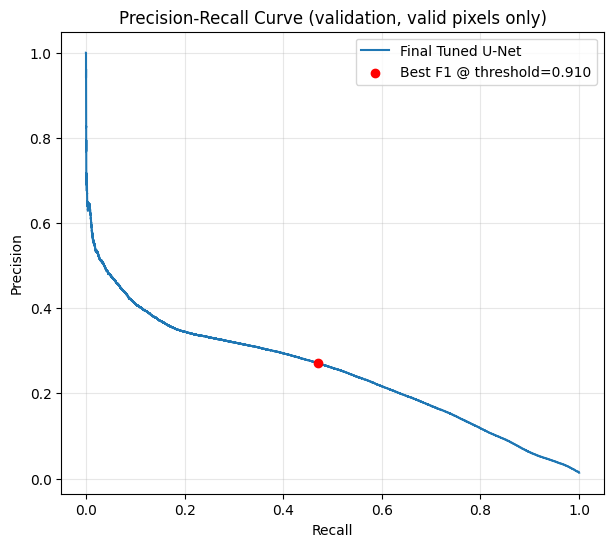

In [ ]:
y_pred_logits_lr = unet_lr_low.predict(X_val, verbose=1, batch_size=8)
y_pred_prob_lr = tf.sigmoid(y_pred_logits_lr[..., 0]).numpy()
y_score_lr = y_pred_prob_lr[valid_mask]

precisions, recalls, thresholds = precision_recall_curve(y_true, y_score_lr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_lr = thresholds[best_idx]

print(f"Best threshold: {best_threshold_lr:.4f}")
print(f"Precision @ best-F1: {precisions[best_idx]:.4f}")
print(f"Recall @ best-F1: {recalls[best_idx]:.4f}")
print(f"F1 @ best-F1: {f1_scores[best_idx]:.4f}")

y_pred_binary_lr = (y_score_lr >= best_threshold_lr).astype(int)
intersection = np.sum((y_pred_binary_lr == 1) & (y_true == 1))
union = np.sum((y_pred_binary_lr == 1) | (y_true == 1))
iou_lr = intersection / union
print(f"IoU @ best-F1: {iou_lr:.4f}")

# Plot the PR curve
plt.figure(figsize=(7,6))
plt.plot(recalls, precisions, label='Final Tuned U-Net')
plt.scatter([best_recall], [best_precision], color='red', zorder=5,
            label=f'Best F1 @ threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (validation, valid pixels only)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This Precision-Recall curve has a few insights. The curve starts near precision=1.0 and recall=0.0, drops steeply, then declines more gradually as recall increases towards 1.0. The shape of this curve reflects that the model confidently ranks fire pixels. As the threshold to capture more true fire pixels is lowered, the precision falls off. Going from a precision of near 1.0 to near 0.4 within the first 0.1-0.15 of recall reflects the class imbalance. 

The red dot marks the best F1 value at a threshold of 0.9103. This F1 score is maximized at a precision of 0.2715 and a recall of 0.4695 and is the model's "best balanced" operating point.

Overall, the curve makes it clear that there is no threshold that simultaneously gives high precision and high recall, which is expected given the class imbalance.

Below, the probability distribution of valid pixels is displayed. There is a small bimodal shape to this distribution (two peaks on either side of the plot), which confirms that the model is confidently sorting most pixels into "probably no-fire" or "probably fire" rather than not picking either.

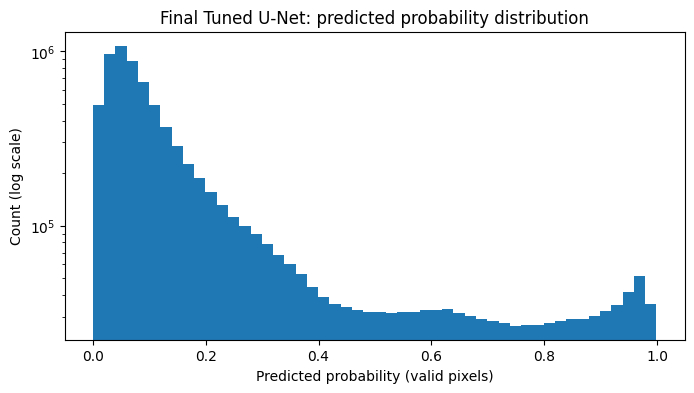

Median predicted prob: 0.0892
Mean predicted prob: 0.1804
% of valid pixels with prob >= 0.5: 10.55%


In [32]:
# Look at the probability distribution for the valid pixels
plt.figure(figsize=(8,4))
plt.hist(y_score_lr, bins=50)
plt.yscale('log')
plt.xlabel('Predicted probability (valid pixels)')
plt.ylabel('Count (log scale)')
plt.title('Final Tuned U-Net: predicted probability distribution')
plt.show()

print(f"Median predicted prob: {np.median(y_score_lr):.4f}")
print(f"Mean predicted prob: {np.mean(y_score_lr):.4f}")
print(f"% of valid pixels with prob >= 0.5: {(y_score_lr >= 0.5).mean()*100:.2f}%")

## Evaluating the Model 

This sections evaluates the best model (U-Net with lower learning rate of 3e-4) on the test data.

In [35]:
# Load the saved best checkpoint from the lr=3e-4 run
unet_lr_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_lr3e4_best.keras'
unet_test_model = tf.keras.models.load_model(
    unet_lr_checkpoint_path,
    custom_objects={'masked_weighted_bce': masked_weighted_bce}
)

# Reconstruct true labels and valid mask from target_test
y_true_full_test = target_test[..., 0]
valid_mask_test = target_test[..., 1] > 0

# Get predictions from the checkpoint
y_pred_logits_test = unet_test_model.predict(X_test, verbose=1, batch_size=8)
y_pred_prob_test = tf.sigmoid(y_pred_logits_test[..., 0]).numpy()

# Flatten to valid pixels only
y_true_test = y_true_full_test[valid_mask_test]
y_score_test = y_pred_prob_test[valid_mask_test]

# AUC
unet_test_auc = roc_auc_score(y_true_test, y_score_test)
print(f"U-Net (LR=3e-4) Test AUC: {unet_test_auc:.4f}")
print(f"U-Net (LR=3e-4) Validation AUC: 0.9341 (for comparison)")

# Precision/Recall/F1 (using a threshold of 0.9103)
y_pred_binary_test = (y_score_test >= best_threshold_lr).astype(int)

precision_test = np.sum((y_pred_binary_test == 1) & (y_true_test == 1)) / (np.sum(y_pred_binary_test == 1) + 1e-10)
recall_test = np.sum((y_pred_binary_test == 1) & (y_true_test == 1)) / (np.sum(y_true_test == 1) + 1e-10)
f1_test = 2 * precision_test * recall_test / (precision_test + recall_test + 1e-10)

intersection_test = np.sum((y_pred_binary_test == 1) & (y_true_test == 1))
union_test = np.sum((y_pred_binary_test == 1) | (y_true_test == 1))
iou_test = intersection_test / union_test

print(f"Precision @ val-threshold: {precision_test:.4f}")
print(f"Recall @ val-threshold: {recall_test:.4f}")
print(f"F1 @ val-threshold: {f1_test:.4f}")
print(f"IoU @ val-threshold: {iou_test:.4f}")

212/212 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step
U-Net (LR=3e-4) Test AUC: 0.9365
U-Net (LR=3e-4) Validation AUC: 0.9341 (for comparison)
Precision @ val-threshold: 0.2761
Recall @ val-threshold: 0.5823
F1 @ val-threshold: 0.3746
IoU @ val-threshold: 0.2305


The Test AUC of 0.9365 appears to be better than the Validation AUC of 0.9341. So, the test data outperformed the validation data, which is not very common. This could be due to distributional variance given the no-fire/fire class imbalance. 

Another potential reason for this could be due to how the train/val/test splits were made. Because our data source has ready-made train/val/test sets, we aren't familiar with how this split happened. It is possible that the split wasn't fully random with respect to time and geography.

Overall, the model appears to perform quite well. It optimally predicts next-day fire spread given the AUC metric.